# 01 — EDA and hinge-form discovery

We start by loading every run in `results_0416b/` and verifying, visually, the structural assumption behind the analysis:

**Claim.** On the *Negotiation* region (where `v ≤ m_t ≤ s_{t-1}`), the seller's next quote `s_t` is well described by a hinged linear function of the merchant's offer relative to the seller's break-even:

$$s_t \;\approx\; \underbrace{\alpha\, s_{t-1}}_{\text{inertia}} \;+\; \underbrace{\beta_+ \,(m_t - v)_+}_{\text{responsive pull when above }v} \;-\; \underbrace{\beta_- \,(v - m_t)_+}_{\text{defensive push below }v} \;+\; \gamma + (\text{small corrections})$$

The hinge point is `v` (break-even), which the seller knows privately. The hypothesis is that the seller's decision *kinks* at that point: offers above `v` are worth engaging with (move toward the merchant), offers below `v` are threatening (push back).

In this notebook we do **no regression yet** — the goal is to *see* the hinges in the raw data and confirm the form holds across the six seller strategies.

> Notebook 02 handles the regression, with robust treatment of the collinearity between `s_t` and `s_{t-1}`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

from analysis_common import (
    load_all_runs, add_hinge_features, NEGOTIATION_MASK,
    SELLER_STRATEGIES, setup_plot_defaults,
)
setup_plot_defaults()

# Load everything under results_0416b/.  To restrict to specific notebooks
# (e.g. only the fixed×fixed sweeps), pass notebooks=['nb1','nb2','nb3','nb4','nb5','nb6'].
df = load_all_runs('results_0416b')
df = add_hinge_features(df)
print(f'Loaded {len(df):,} transitions from {df["run_idx"].nunique()} runs '
      f'({df["notebook_id"].nunique()} notebooks).')

[analysis_common] discovered 432 condition files under results_0416b
[analysis_common] built 38090 transition rows from 2748 unique runs
Loaded 38,090 transitions from 2748 runs (12 notebooks).


## 1. Overall dataset summary

In [2]:
print('by notebook:')
display(df.groupby('notebook_id').size().rename('n_rows').to_frame())
print('\nby seller strategy (per-round):')
display(df['supplier_active_strategy_curr'].value_counts().to_frame('n_rows'))
print('\nby buyer active strategy (per-round):')
display(df['buyer_active_strategy'].value_counts().head(20).to_frame('n_rows'))
print('\nregion breakdown:')
display(df['region'].value_counts(normalize=True).round(3).to_frame('frac'))

by notebook:


,n_rows
notebook_id,
nb1,3061
nb10,3330
nb11,3476
nb12,3005
nb2,3055
nb3,3067
nb4,3050
nb5,2981
nb6,3060



by seller strategy (per-round):


,n_rows
supplier_active_strategy_curr,
anchor_high,7536
cooperative,7410
boulware_seller,7264
conceder_seller,6787
tit_for_tat_matcher,4605
relational,4488



by buyer active strategy (per-round):


,n_rows
buyer_active_strategy,
concession,4923
tit_for_tat_buyer,4571
anchor_drag,3929
boulware_buyer,3757
wild,3630
budget,3608
conceder_buyer,3529
persistent_f0.30,3499
random,3459



region breakdown:


,frac
region,
Low,0.739
Negotiation,0.261


### Product economics — sanity check

We sampled product cost, market price, and internal cost from continuous ranges. The histogram below confirms we get coverage across the whole realistic retail spread, not the tight discrete grid of the 0413 data.

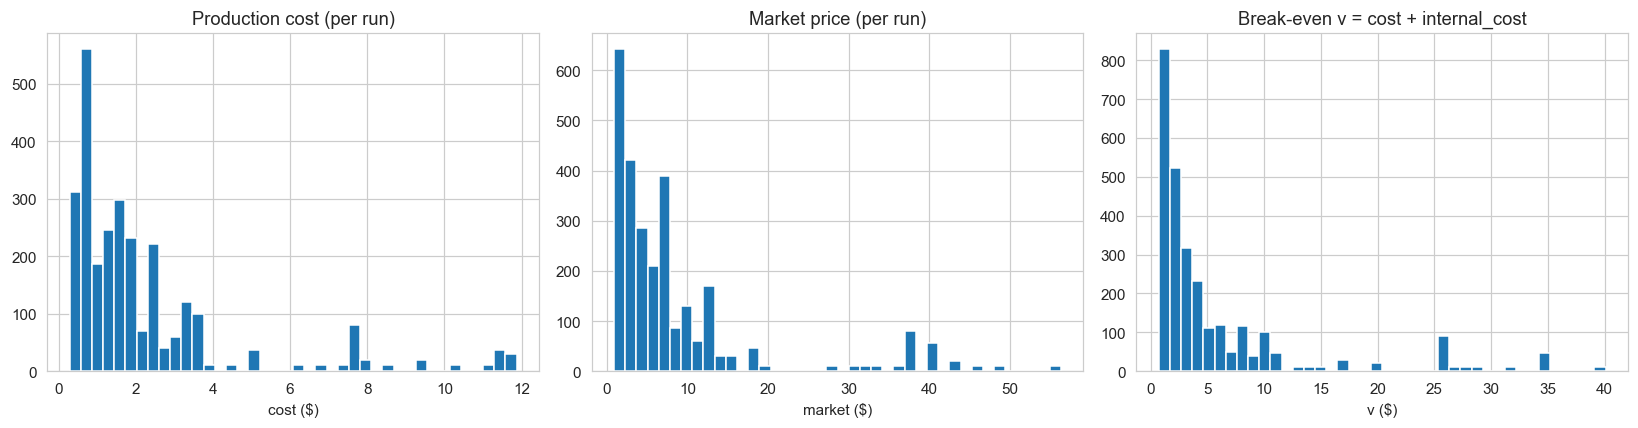

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
one_per_run = df.drop_duplicates('run_idx')
axes[0].hist(one_per_run['cost'], bins=40)
axes[0].set_title('Production cost (per run)'); axes[0].set_xlabel('cost ($)')
axes[1].hist(one_per_run['market'], bins=40)
axes[1].set_title('Market price (per run)'); axes[1].set_xlabel('market ($)')
axes[2].hist(one_per_run['v'], bins=40)
axes[2].set_title('Break-even v = cost + internal_cost'); axes[2].set_xlabel('v ($)')
plt.tight_layout(); plt.show()

## 2. Visual evidence of the hinge at v

We take the **Negotiation** subset (no easy-accept or easy-reject cases) and plot the seller's response, normalized by the bargaining-zone width `(market − cost)`, against the signed distance from break-even `(m_t − v)`.

Normalization matters because prices vary across products from \$0.50 cola to \$30 USB adapters — without it, raw scatter is dominated by scale. After normalization, a **single** curve should emerge across all products if the hinge form holds.

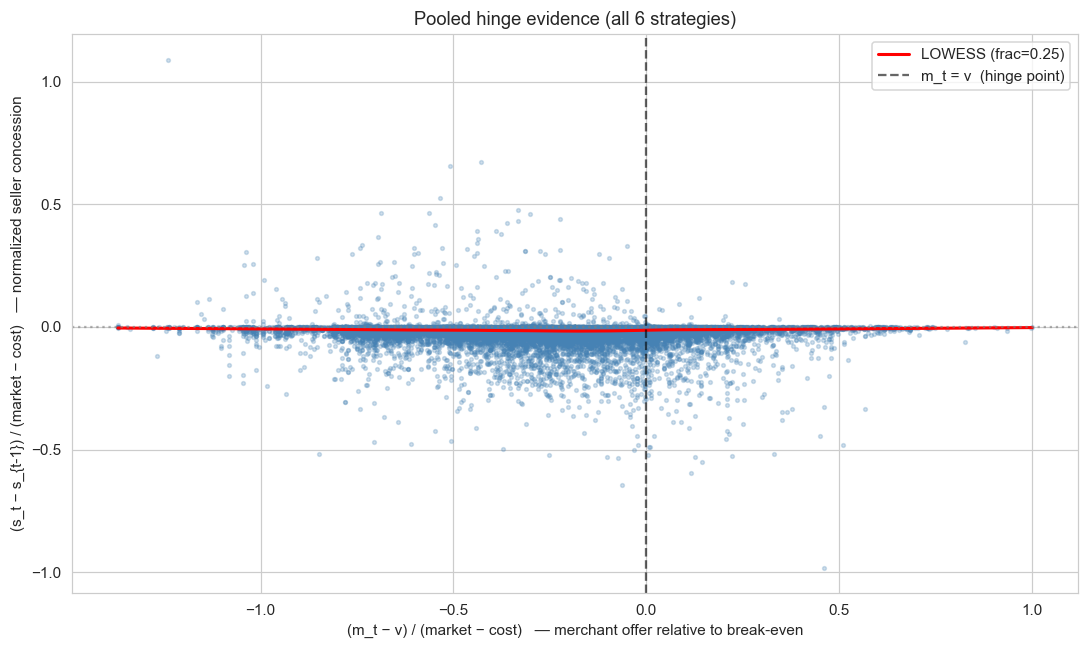

Interpretation: a kink at x=0 (m_t = v) would confirm a hinged response.
Left of 0: merchant offers below break-even → seller barely concedes (or holds).
Right of 0: merchant offers above break-even → seller concedes more aggressively.


In [4]:
nego = df[NEGOTIATION_MASK(df) & (df['round_t'] <= 8)].copy()
zone = (nego['market'] - nego['cost']).clip(lower=1e-3)
nego['x_norm'] = (nego['m_t'] - nego['v']) / zone          # signed distance from v
nego['y_norm'] = (nego['s_t'] - nego['s_prev']) / zone    # normalized concession

plt.figure(figsize=(10, 6))
plt.scatter(nego['x_norm'], nego['y_norm'], s=6, alpha=0.25, color='steelblue')
sm = lowess(nego['y_norm'], nego['x_norm'], frac=0.25, return_sorted=True)
plt.plot(sm[:, 0], sm[:, 1], 'r-', lw=2, label='LOWESS (frac=0.25)')
plt.axvline(0, color='k', ls='--', alpha=0.6, label='m_t = v  (hinge point)')
plt.axhline(0, color='grey', ls=':', alpha=0.6)
plt.xlabel('(m_t − v) / (market − cost)   — merchant offer relative to break-even')
plt.ylabel('(s_t − s_{t-1}) / (market − cost)   — normalized seller concession')
plt.title('Pooled hinge evidence (all 6 strategies)')
plt.legend()
plt.tight_layout(); plt.show()
print('Interpretation: a kink at x=0 (m_t = v) would confirm a hinged response.\n'
      'Left of 0: merchant offers below break-even → seller barely concedes (or holds).\n'
      'Right of 0: merchant offers above break-even → seller concedes more aggressively.')

### Per-strategy hinge plots

Each seller strategy should have its own characteristic hinge — `cooperative` should pull closer to the merchant, `anchor_high` should barely move, `boulware_seller` should be nearly flat on both sides, etc. These are the *empirical fingerprints* that notebook 03 will quantify.

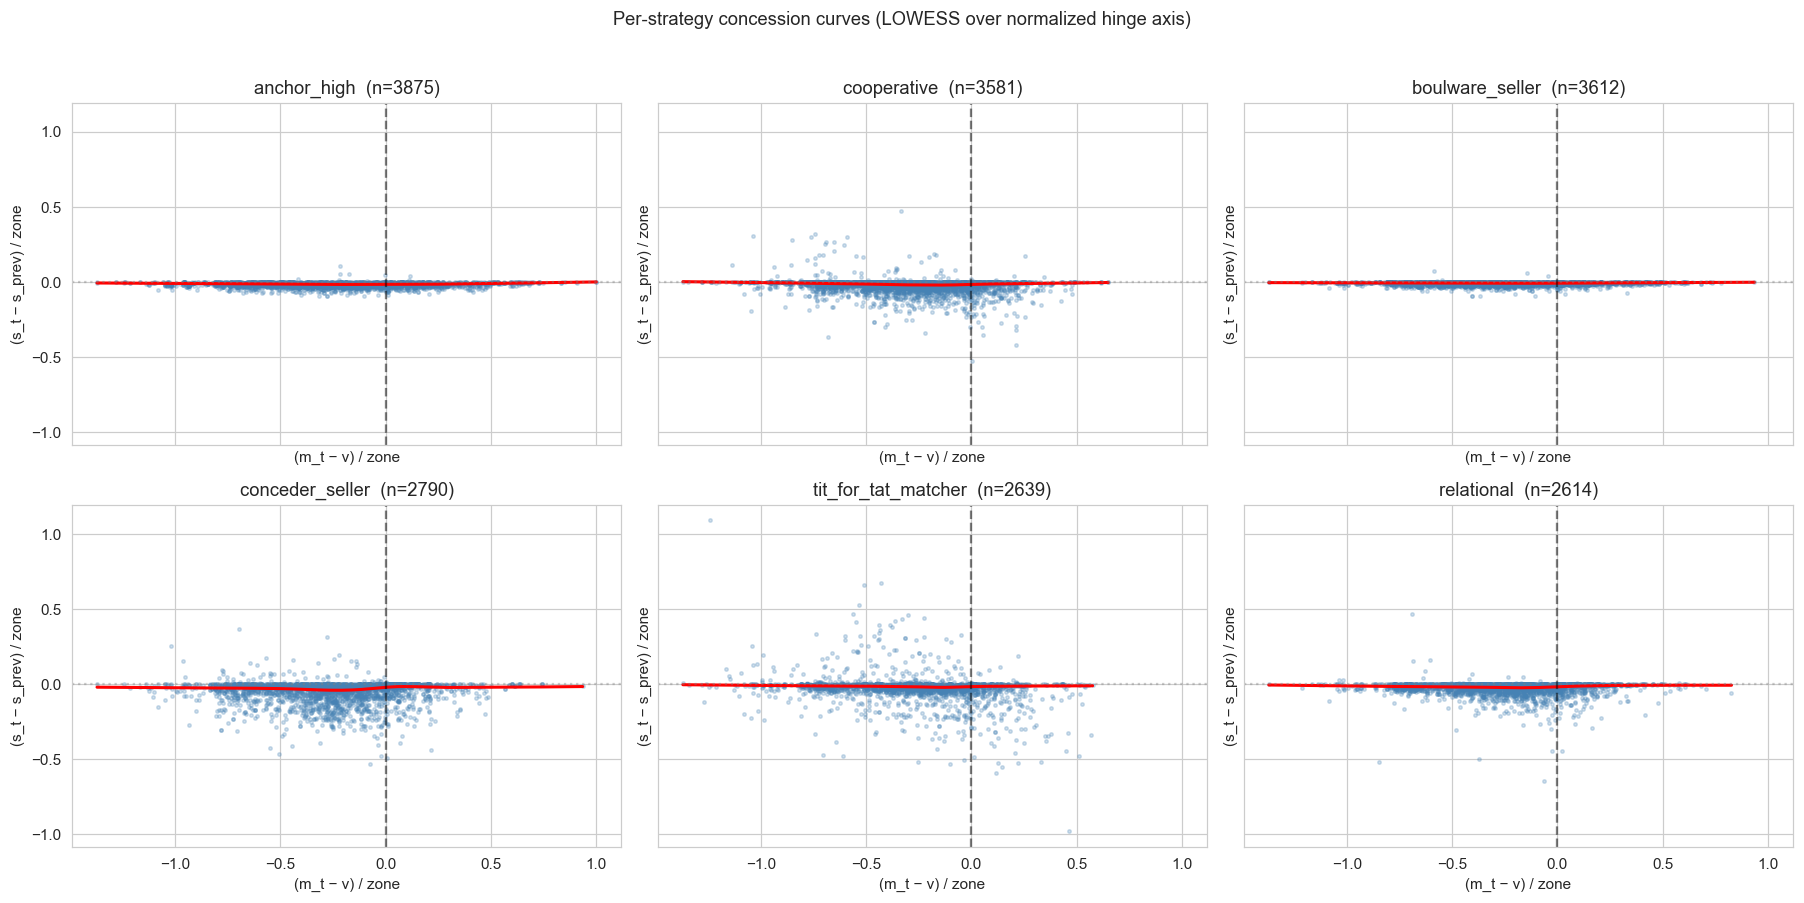

In [5]:
strategies_present = [s for s in SELLER_STRATEGIES
                      if s in nego['supplier_active_strategy_curr'].unique()]
n = len(strategies_present); ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()
for ax, strat in zip(axes, strategies_present):
    sub = nego[nego['supplier_active_strategy_curr'] == strat]
    if len(sub) < 20:
        ax.set_visible(False); continue
    ax.scatter(sub['x_norm'], sub['y_norm'], s=5, alpha=0.25, color='steelblue')
    sm = lowess(sub['y_norm'], sub['x_norm'], frac=0.35, return_sorted=True)
    ax.plot(sm[:, 0], sm[:, 1], 'r-', lw=2)
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.axhline(0, color='grey', ls=':', alpha=0.4)
    ax.set_title(f'{strat}  (n={len(sub)})')
    ax.set_xlabel('(m_t − v) / zone'); ax.set_ylabel('(s_t − s_prev) / zone')
for j in range(len(strategies_present), len(axes)): axes[j].set_visible(False)
plt.suptitle('Per-strategy concession curves (LOWESS over normalized hinge axis)', y=1.02)
plt.tight_layout(); plt.show()

## 3. Second hinge: the seller's own concession history

The other hinge your example notebooks test is on `Δs_{t-1} = s_{t-1} − s_{t-2}`:
- `ds_neg = max(−Δs_{t-1}, 0)`: the seller lowered their quote last turn (a concession)
- `ds_pos = max( Δs_{t-1}, 0)`: the seller raised their quote last turn (rare)

The hypothesis is that the seller's **continued** concession rate reacts asymmetrically to their own history: once started conceding, a `tit_for_tat_matcher` keeps conceding if the buyer rewards them but halts if the buyer doesn't. This split is what the `ds_pos` / `ds_neg` hinge captures.

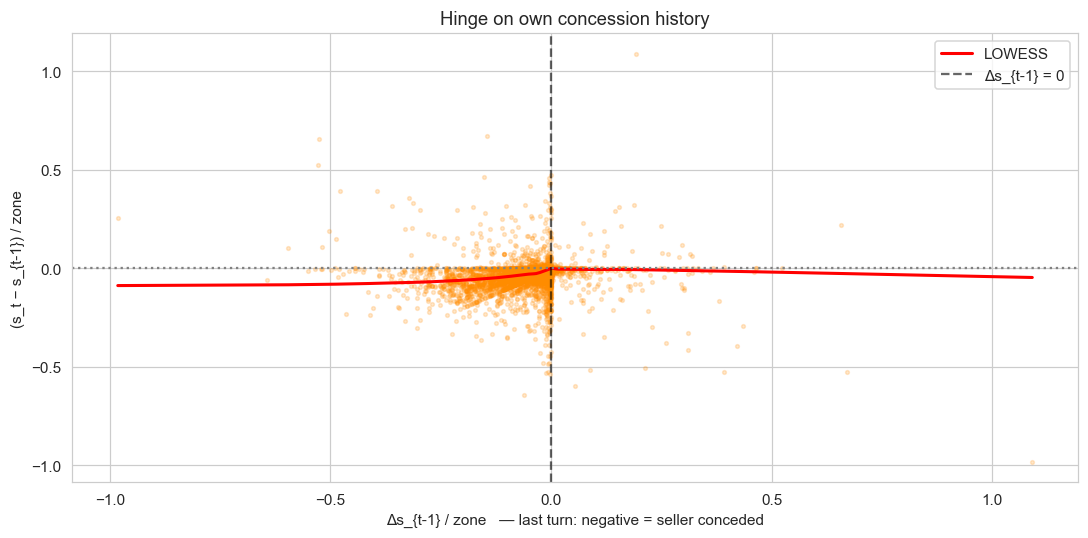

If the curve kinks at Δs_{t-1}=0, concession persists asymmetrically.


In [6]:
nego2 = nego.dropna(subset=['ds_prev']).copy()
nego2['ds_norm'] = nego2['ds_prev'] / zone.loc[nego2.index]
plt.figure(figsize=(10, 5))
plt.scatter(nego2['ds_norm'], nego2['y_norm'], s=6, alpha=0.2, color='darkorange')
sm = lowess(nego2['y_norm'], nego2['ds_norm'], frac=0.3, return_sorted=True)
plt.plot(sm[:, 0], sm[:, 1], 'r-', lw=2, label='LOWESS')
plt.axvline(0, color='k', ls='--', alpha=0.6, label='Δs_{t-1} = 0')
plt.axhline(0, color='grey', ls=':')
plt.xlabel('Δs_{t-1} / zone   — last turn: negative = seller conceded')
plt.ylabel('(s_t − s_{t-1}) / zone')
plt.title('Hinge on own concession history')
plt.legend(); plt.tight_layout(); plt.show()
print('If the curve kinks at Δs_{t-1}=0, concession persists asymmetrically.')

## 4. Joint view — 2-D binned concession surface

A 2-D hexbin of `(x_norm, y_norm)` lets us eyeball the joint shape. The hinge should appear as a **brightness discontinuity** in the mean `y_norm` along the `x_norm = 0` line.

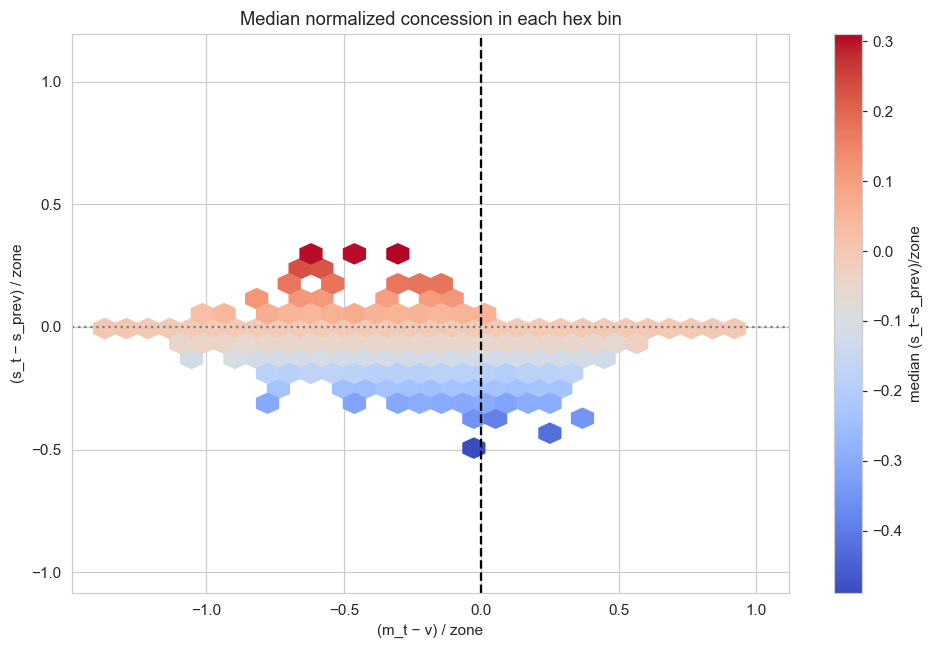

In [7]:
from matplotlib import cm

fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(nego['x_norm'], nego['y_norm'], gridsize=30,
               reduce_C_function=np.median, C=nego['y_norm'],
               cmap='coolwarm', mincnt=3)
ax.axvline(0, color='k', ls='--')
ax.axhline(0, color='grey', ls=':')
ax.set_xlabel('(m_t − v) / zone'); ax.set_ylabel('(s_t − s_prev) / zone')
ax.set_title('Median normalized concession in each hex bin')
plt.colorbar(hb, ax=ax, label='median (s_t−s_prev)/zone')
plt.tight_layout(); plt.show()

## 5. Takeaways

- The pooled hinge plot should show two visually different slopes on either side of `x_norm = 0` (the break-even boundary). If the LOWESS curve is a single straight line through the origin, the hinge form is *not* needed — a plain linear model would do.
- The per-strategy panels show that the hinge *location* is the same for all strategies (`v`), but the *slopes* differ. This is the signal notebook 03 will quantify.
- The second-hinge panel tests whether the seller's own concession history carries additional information beyond `(m_t, v)`. If yes, `ds_pos` / `ds_neg` earn their place in the regression.

Notebook 02 moves from qualitative to quantitative: it fits the hinge model with robust methods that handle the `s_t` / `s_{t-1}` collinearity.